# Bayesian Network (BN) Analysis of a Smart Hospital Monitoring System



#Scenario Overview

In a modern hospital environment:

- Sensors continuously monitor patient conditions  
- Network systems transmit data to monitoring stations  
- Medical staff respond based on alerts  

However, failures can occur at different levels:

- Sensor failures  
- Network failures  
- Monitoring errors  
- Delayed staff response  

These failures can combine and increase the likelihood of **patient risk**.




#  Install Libraries, Import Packages, and Define Helper Functions

This block installs and imports all libraries needed for Bayesian Network modelling.

It also defines two helper functions:

- `print_header()` for main headings
- `print_subheader()` for smaller section headings

In [2]:
# Install required libraries for Bayesian Network modelling and visualization
!pip install pgmpy networkx matplotlib pandas

# Import pandas for table handling
import pandas as pd

# Import matplotlib for plotting the Bayesian Network graph
import matplotlib.pyplot as plt

# Import networkx for creating and drawing graph structures
import networkx as nx

# Import Bayesian Network model class from pgmpy
from pgmpy.models import DiscreteBayesianNetwork

# Import TabularCPD for defining probability tables
from pgmpy.factors.discrete import TabularCPD

# Import VariableElimination for probabilistic inference
from pgmpy.inference import VariableElimination


def print_header(title: str, width: int = 100) -> None:
    # Print a blank line and top border
    print("\n" + "=" * width)

    # Print centered title
    print(title.center(width))

    # Print bottom border
    print("=" * width)


def print_subheader(title: str, width: int = 100) -> None:
    # Print a blank line and top separator
    print("\n" + "-" * width)

    # Print subheading text
    print(title)

    # Print bottom separator
    print("-" * width)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 39.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.8/163.8 kB 11.0 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/pgmpy/estimators/__init__.py:4: FutureWarning: `pgmpy.estimators.StructureScore` is deprecated and will be removed in a future release. Use `pgmpy.structure_score` instead.
  from .StructureScore import (


#  Define the Bayesian Network Structure

This block defines the structure of the Bayesian Network.

The model has five nodes:

1. SensorFailure
2. NetworkFailure
3. MonitoringError
4. StaffResponseDelay
5. PatientRisk

The arrows show cause-and-effect relationships.

For example:

- Sensor failure can cause monitoring error.
- Network failure can cause monitoring error.
- Monitoring error can delay staff response.
- Delayed staff response can increase patient risk.

In [3]:
# Create the Bayesian Network structure using directed edges
model = DiscreteBayesianNetwork([

    # Sensor failure can cause monitoring error
    ("SensorFailure", "MonitoringError"),

    # Network failure can also cause monitoring error
    ("NetworkFailure", "MonitoringError"),

    # Monitoring error can cause staff response delay
    ("MonitoringError", "StaffResponseDelay"),

    # Staff response delay can increase patient risk
    ("StaffResponseDelay", "PatientRisk"),
])

#  Define Conditional Probability Tables

This block defines the Conditional Probability Distributions, also called CPDs.

A CPD tells the model how likely each node state is.

Each node has two states:

- No
- Yes

For parent nodes such as `SensorFailure`, the probabilities are simple prior probabilities.

For child nodes such as `MonitoringError`, the probabilities depend on parent node states.

In [4]:
# Define CPD for SensorFailure
cpd_sensor = TabularCPD(
    # Variable name
    variable="SensorFailure",

    # Two states: No and Yes
    variable_card=2,

    # Probability values: P(No)=0.94, P(Yes)=0.06
    values=[[0.94], [0.06]],

    # State labels
    state_names={"SensorFailure": ["No", "Yes"]}
)


# Define CPD for NetworkFailure
cpd_network = TabularCPD(
    # Variable name
    variable="NetworkFailure",

    # Two states: No and Yes
    variable_card=2,

    # Probability values: P(No)=0.91, P(Yes)=0.09
    values=[[0.91], [0.09]],

    # State labels
    state_names={"NetworkFailure": ["No", "Yes"]}
)


# Define CPD for MonitoringError
cpd_monitoring_error = TabularCPD(
    # Child variable
    variable="MonitoringError",

    # Two states: No and Yes
    variable_card=2,

    # Conditional probabilities for MonitoringError
    values=[
        # P(MonitoringError = No) for each parent combination
        [0.98, 0.55, 0.45, 0.10],

        # P(MonitoringError = Yes) for each parent combination
        [0.02, 0.45, 0.55, 0.90],
    ],

    # Parent variables
    evidence=["SensorFailure", "NetworkFailure"],

    # Each parent has two states
    evidence_card=[2, 2],

    # State labels for child and parents
    state_names={
        "MonitoringError": ["No", "Yes"],
        "SensorFailure": ["No", "Yes"],
        "NetworkFailure": ["No", "Yes"]
    }
)


# Define CPD for StaffResponseDelay
cpd_delay = TabularCPD(
    # Child variable
    variable="StaffResponseDelay",

    # Two states: No and Yes
    variable_card=2,

    # Conditional probabilities depending on MonitoringError
    values=[
        # P(StaffResponseDelay = No)
        [0.87, 0.35],

        # P(StaffResponseDelay = Yes)
        [0.13, 0.65],
    ],

    # Parent variable
    evidence=["MonitoringError"],

    # Parent has two states
    evidence_card=[2],

    # State labels
    state_names={
        "StaffResponseDelay": ["No", "Yes"],
        "MonitoringError": ["No", "Yes"]
    }
)


# Define CPD for PatientRisk
cpd_risk = TabularCPD(
    # Final outcome variable
    variable="PatientRisk",

    # Two states: No and Yes
    variable_card=2,

    # Conditional probabilities depending on StaffResponseDelay
    values=[
        # P(PatientRisk = No)
        [0.97, 0.30],

        # P(PatientRisk = Yes)
        [0.03, 0.70],
    ],

    # Parent variable
    evidence=["StaffResponseDelay"],

    # Parent has two states
    evidence_card=[2],

    # State labels
    state_names={
        "PatientRisk": ["No", "Yes"],
        "StaffResponseDelay": ["No", "Yes"]
    }
)


# Add all CPDs to the Bayesian Network model
model.add_cpds(
    cpd_sensor,
    cpd_network,
    cpd_monitoring_error,
    cpd_delay,
    cpd_risk
)


# Check whether the Bayesian Network is valid
assert model.check_model(), "The Bayesian Network model is invalid."

#  Perform Bayesian Inference

This block uses Variable Elimination to answer probability questions.

The queries are:

1. What is the prior probability of patient risk?
2. What is the probability of patient risk if sensor failure occurs?
3. What is the probability of patient risk if both sensor failure and network failure occur?

This helps show how evidence changes the final risk.

In [5]:
# Create inference engine using Variable Elimination
inference = VariableElimination(model)

# Print main results heading
print_header("SMART HOSPITAL BAYESIAN NETWORK RESULTS")


# Query 1: Prior probability of PatientRisk
print_subheader("1. Prior Probability of Patient Risk")

# Compute PatientRisk probability without evidence
result1 = inference.query(variables=["PatientRisk"])

# Print result
print(result1)


# Query 2: Probability of PatientRisk given SensorFailure = Yes
print_subheader("2. Probability of Patient Risk Given Sensor Failure = Yes")

# Compute PatientRisk probability with sensor failure evidence
result2 = inference.query(
    variables=["PatientRisk"],
    evidence={"SensorFailure": "Yes"}
)

# Print result
print(result2)


# Query 3: Probability of PatientRisk given SensorFailure = Yes and NetworkFailure = Yes
print_subheader("3. Probability of Patient Risk Given Sensor Failure = Yes and Network Failure = Yes")

# Compute PatientRisk probability with both sensor and network failure evidence
result3 = inference.query(
    variables=["PatientRisk"],
    evidence={
        "SensorFailure": "Yes",
        "NetworkFailure": "Yes"
    }
)

# Print result
print(result3)


                              SMART HOSPITAL BAYESIAN NETWORK RESULTS                               

----------------------------------------------------------------------------------------------------
1. Prior Probability of Patient Risk
----------------------------------------------------------------------------------------------------
+------------------+--------------------+
| PatientRisk      |   phi(PatientRisk) |
+==================+====================+
| PatientRisk(No)  |             0.8515 |
+------------------+--------------------+
| PatientRisk(Yes) |             0.1485 |
+------------------+--------------------+

----------------------------------------------------------------------------------------------------
2. Probability of Patient Risk Given Sensor Failure = Yes
----------------------------------------------------------------------------------------------------
+------------------+--------------------+
| PatientRisk      |   phi(PatientRisk) |
+==================

#  Visualize the Bayesian Network

This block draws the Bayesian Network graph.

Each node represents a variable.

Each arrow shows a dependency relationship.

For example:

`SensorFailure → MonitoringError`

means sensor failure influences the probability of monitoring error.

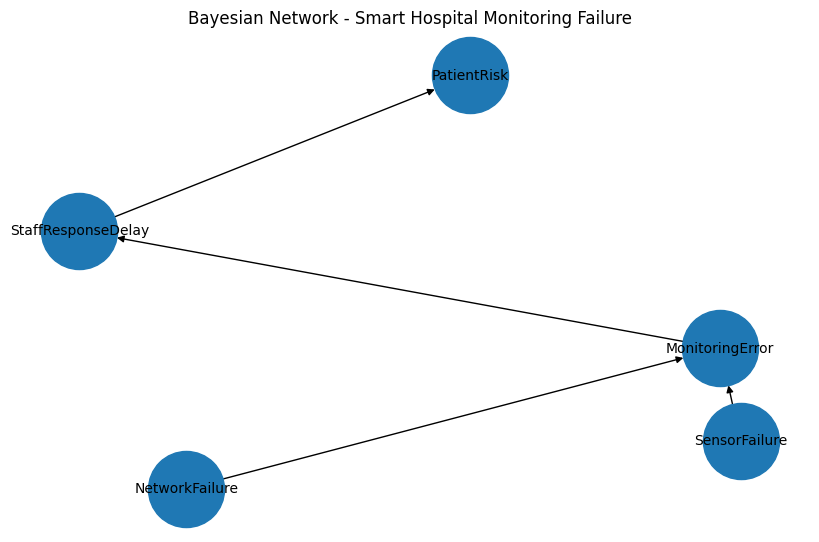

In [6]:
# Create a directed graph object
graph = nx.DiGraph()

# Add Bayesian Network edges to the graph
graph.add_edges_from(model.edges())

# Create figure size
plt.figure(figsize=(8, 5))

# Compute positions for nodes
pos = nx.spring_layout(graph, seed=42)

# Draw graph
nx.draw(
    graph,
    pos,
    with_labels=True,
    node_size=3000,
    font_size=10,
    arrows=True
)

# Add graph title
plt.title("Bayesian Network - Smart Hospital Monitoring Failure")

# Display graph
plt.show()